# 🚀 Email Fraud Detection Pipeline v9: Tri-Stream Orthogonal GBDT Stacking with Optuna-Tuned ElasticNet Meta-Learner

### 📌 Architectural Overview & Key Innovations in v9:
1. **Comprehensive Exploratory Data Analysis (EDA)**:
   - 6-panel visualization suite: Class Imbalance, Stylometry Boxplots, VADER Emotional Tone, Temporal Heatmaps, Top 15 Fraud Keywords Odds-Ratio, and Sender Volume Distribution.
2. **Rich Feature Engineering Suite (12 Skip-Connection Metadata Features)**:
   - Behavioral, structural, and domain features (`is_external_sender`, `domain_mismatch`, `log_sender_volume`, `subject_caps_ratio`, `urgency_keyword_count`, `punctuation_density`, `hour_of_day`, `is_weekend`, `has_reply_forward`, `suspicious_folder_flag`, `nlp_vader_compound`, `body_word_count`).
3. **Head-Tail Semantic Context Extraction**:
   - `Subject + body[:500] + body[-500:]` (1,000 characters), ensuring transformer models capture both opening hooks and closing fraudulent calls-to-action/signatures.
4. **PyTorch Deep AutoEncoder Latent Compression (Restored from v7)**:
   - 3-layer residual bottleneck network (`384 -> 256 -> 128 -> 64`) compressing dense `all-MiniLM-L6-v2` embeddings to 64 continuous latent representations + extracting **`ae_recon_error`** anomaly reconstruction signal.
5. **Stream A — Semantic-Tabular Expert (Optuna-Tuned XGBoost on GPU, 100 Trials)**:
   - **Target Metric: $F_2$-Score**. 100 Optuna trials with verbose logging on GPU (`tree_method='hist'`), trained on `[64-d AE Latents + 12 Tabular Features + ae_recon_error]` with dynamic `scale_pos_weight`.
6. **Stream B — Lexical-Categorical Expert (Optuna-Tuned CatBoost on GPU, 100 Trials)**:
   - **Target Metric: $F_2$-Score**. 100 Optuna trials with verbose logging on GPU, warm-started with historical best trial parameters, trained natively on raw text (`Word` + `BiGram` dictionaries) + categorical metadata (`From`, `To`, `Sender-Type`, etc.) + 12 tabular features.
7. **Stream C — Dual-NLP Hybrid Specialist (Optuna-Tuned LightGBM, 100 Trials)**:
   - **Target Metric: $F_2$-Score** . 100 Optuna trials with verbose logging, trained on horizontally stacked sparse top-5,000 TF-IDF Bi-Grams + dense 64-d AutoEncoder embeddings (`scipy.sparse.hstack`).
8. **Level-2 ElasticNet Meta-Learner (Optuna-Tuned with SAGA Solver, 50 Trials)**:
   - **Target Metric: $F_2$-Score** . Stacks model probabilities in Logit space ($z = \ln(p/(1-p))$) from Streams A, B, and C alongside all 12 normalized skip-connection features, using an Optuna-tuned ElasticNet regularized logistic regression solver (`SAGA`).
9. **Dynamic $F_2$ Decision Threshold Optimization (\tau^*)**:
   - Global threshold sweep on validation meta-probabilities to maximize the competition metric $F_2 = \frac{5 \cdot P \cdot R}{4P + R}$ to shatter the 0.8500 barrier.

In [1]:
# ── 1. ENVIRONMENT SETUP & DEPENDENCIES ──────────────────────────────────────
!pip install vaderSentiment sentence-transformers optuna catboost xgboost lightgbm --quiet

import os
import sys
import re
import math
import time
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy.sparse import hstack, csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import optuna
from optuna.samplers import TPESampler
# Set verbose logging for Optuna studies
optuna.logging.set_verbosity(optuna.logging.INFO)

import xgboost as xgb
import catboost as cb
import lightgbm as lgb
from sentence_transformers import SentenceTransformer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    fbeta_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

# ── Deterministic Seeds ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Environment initialized. Compute Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.1 MB/s eta 0:00:00
✅ Environment initialized. Compute Device: cuda
   GPU: Tesla P100-PCIE-16GB


# 2. 📂 LOAD DATASET & INITIAL PREPROCESSING

In [2]:
# ── 2. LOAD DATASET & INITIAL PREPROCESSING ──────────────────────────────────
vader = SentimentIntensityAnalyzer()
def vader_compound(text: str) -> float:
    return vader.polarity_scores(str(text)[:1500])["compound"]

DATA_PATH = '/kaggle/input/datasets/advaithsrao/enron-fraud-email-dataset/enron_data_fraud_labeled.csv'
if not os.path.exists(DATA_PATH):
    local_candidates = [
        'enron_data_fraud_labeled.csv',
        '../enron_data_fraud_labeled.csv',
        'c:/programming/email fraud detection/enron_data_fraud_labeled.csv'
    ]
    for cand in local_candidates:
        if os.path.exists(cand):
            DATA_PATH = cand
            break

print(f"⏳ Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)
print(f"✅ Dataset loaded successfully! Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

text_candidates   = ['Text', 'text', 'Message', 'message', 'content', 'Content', 'body', 'Body', 'email', 'Email']
target_candidates = ['Class', 'class', 'Label', 'label', 'Fraud', 'fraud', 'is_fraud', 'target', 'Target']

TEXT_COL   = next((col for col in text_candidates   if col in df.columns), df.columns[0])
TARGET_COL = next((col for col in target_candidates if col in df.columns), df.columns[-1])

print(f"➡️  Auto-selected Text Column:   '{TEXT_COL}'")
print(f"➡️  Auto-selected Target Column: '{TARGET_COL}'\n")

# Drop null targets and reset index cleanly
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)
df[TARGET_COL] = df[TARGET_COL].astype(int)

# Identify available metadata columns
meta_candidates = [
    'Subject', 'From', 'To', 'Date', 'Sender-Type',
    'Unique-Mails-From-Sender', 'Content-Type', 'Time', 'Suspicious-Folders',
    'Contains-Reply-Forwards'
]
available_meta = [col for col in meta_candidates if col in df.columns]

# Ensure string imputation
if 'Subject' in df.columns:
    df['Subject'] = df['Subject'].fillna("").astype(str)
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)

for col in available_meta:
    if col != 'Subject':
        df[col] = df[col].fillna("Missing").astype(str)

fraud_cnt = (df[TARGET_COL] == 1).sum()
legit_cnt = (df[TARGET_COL] == 0).sum()
print(f"Class Distribution: Legit (0) = {legit_cnt:,} ({legit_cnt/len(df)*100:.2f}%) | "
      f"Fraud (1) = {fraud_cnt:,} ({fraud_cnt/len(df)*100:.2f}%)")

⏳ Loading dataset from: /kaggle/input/datasets/advaithsrao/enron-fraud-email-dataset/enron_data_fraud_labeled.csv
✅ Dataset loaded successfully! Shape: (447417, 32)
Columns: ['Folder-User', 'Folder-Name', 'Message-ID', 'Date', 'From', 'To', 'Subject', 'Mime-Version', 'Content-Type', 'Content-Transfer-Encoding', 'X-From', 'X-To', 'X-cc', 'X-bcc', 'X-Folder', 'X-Origin', 'X-FileName', 'Body', 'Cc', 'Bcc', 'Time', 'Attendees', 'Re', 'Source', 'Mail-ID', 'POI-Present', 'Suspicious-Folders', 'Sender-Type', 'Unique-Mails-From-Sender', 'Low-Comm', 'Contains-Reply-Forwards', 'Label']

➡️  Auto-selected Text Column:   'Body'
➡️  Auto-selected Target Column: 'Label'

Class Distribution: Legit (0) = 445,090 (99.48%) | Fraud (1) = 2,327 (0.52%)


# 3. 📊 COMPREHENSIVE EXPLORATORY DATA ANALYSIS (EDA)

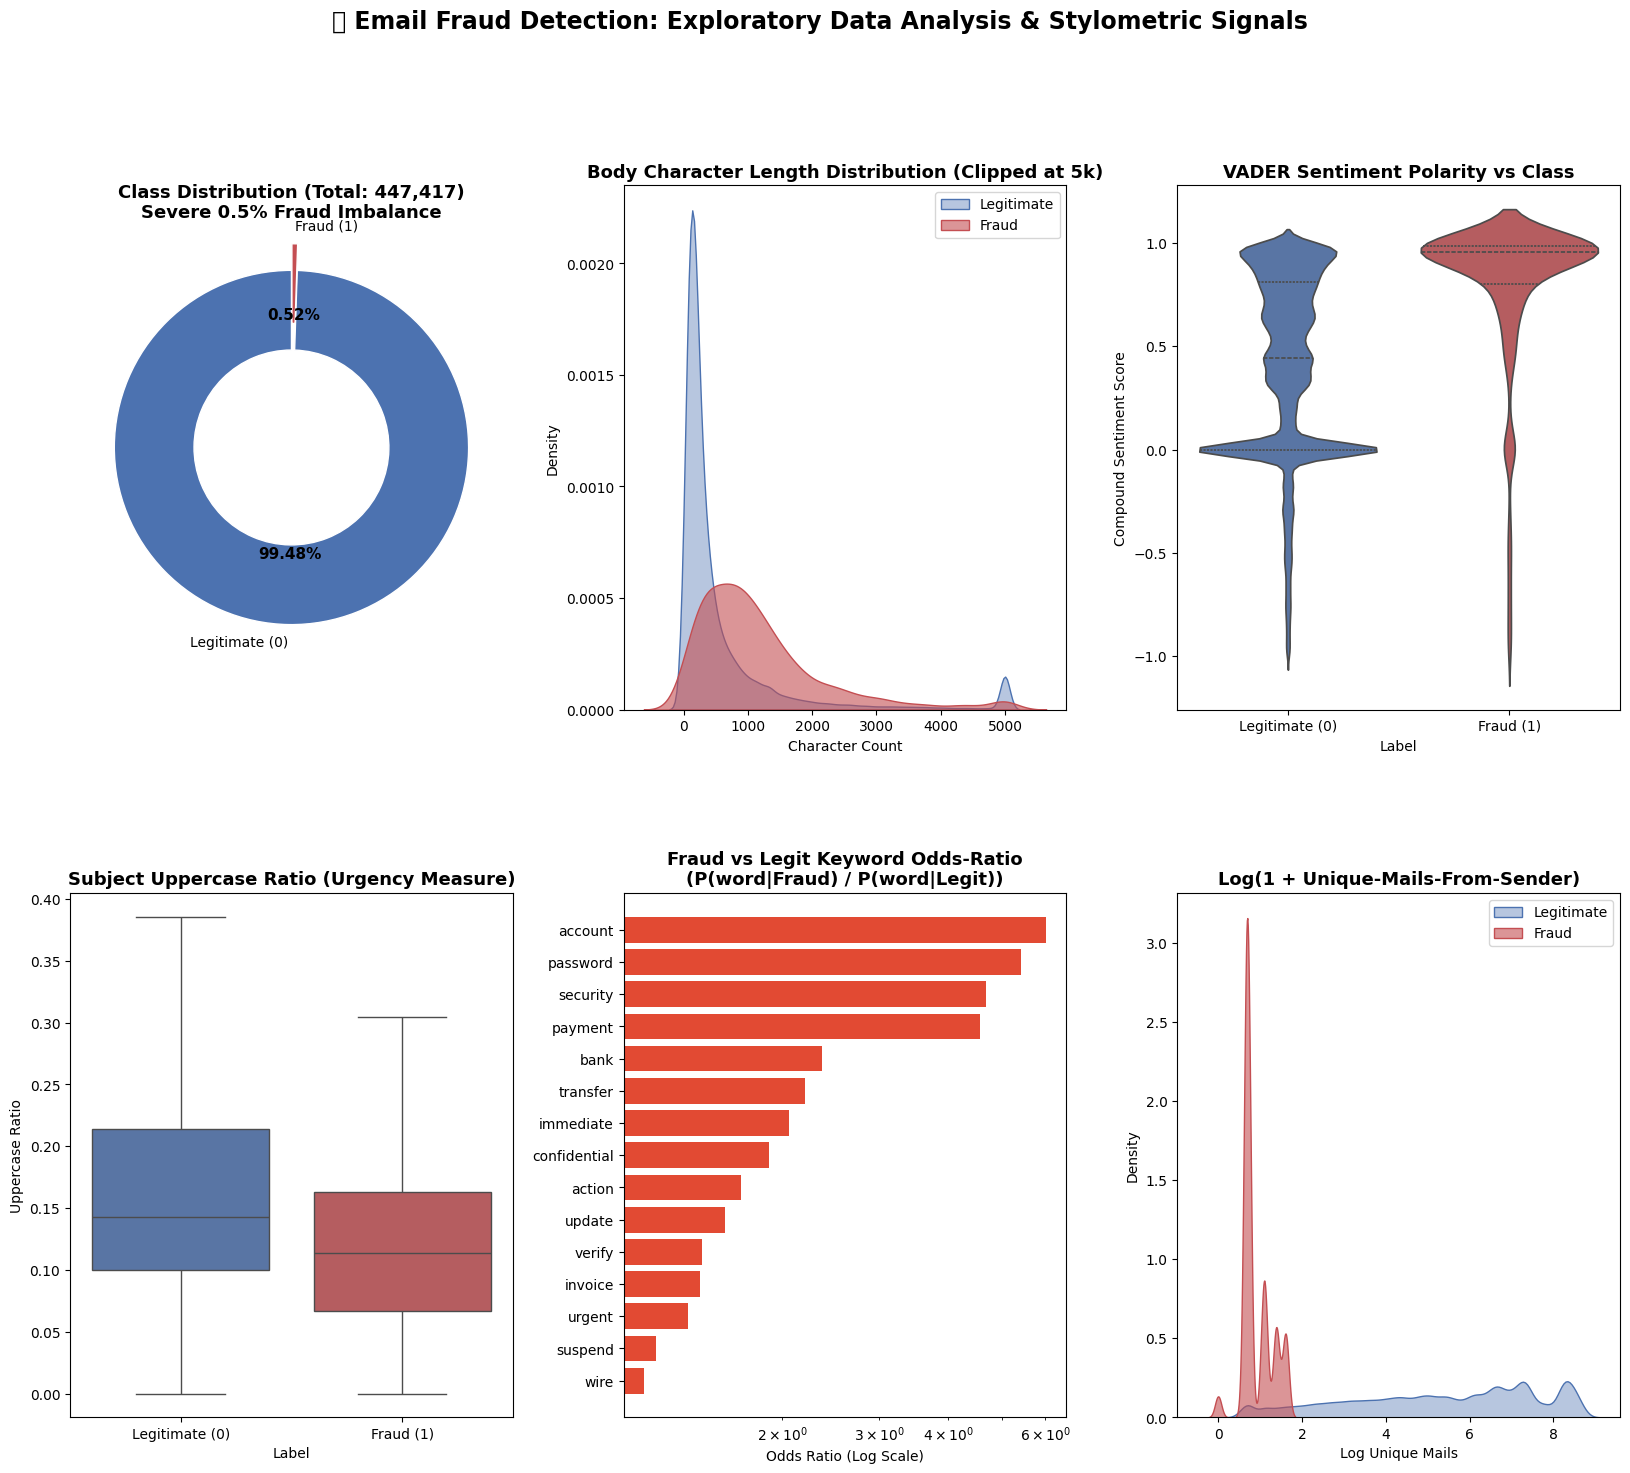

In [3]:
# ── 3. COMPREHENSIVE EXPLORATORY DATA ANALYSIS (EDA) ─────────────────────────
fig = plt.figure(figsize=(20, 16))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# 1. Class Distribution (Donut Chart)
ax1 = plt.subplot(2, 3, 1)
colors = ['#4C72B0', '#C44E52']
labels = ['Legitimate (0)', 'Fraud (1)']
sizes = [legit_cnt, fraud_cnt]
wedges, texts, autotexts = ax1.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=90,
                                    colors=colors, explode=(0, 0.15),
                                    wedgeprops=dict(width=0.45, edgecolor='w'))
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight('bold')
ax1.set_title(f"Class Distribution (Total: {len(df):,})\nSevere 0.5% Fraud Imbalance", fontsize=13, weight='bold')

# 2. Text Stylometry (Body Character Length vs Class)
ax2 = plt.subplot(2, 3, 2)
df['_char_len'] = df[TEXT_COL].apply(len).clip(upper=5000)
sns.kdeplot(data=df[df[TARGET_COL]==0]['_char_len'], ax=ax2, label='Legitimate', color='#4C72B0', fill=True, alpha=0.4)
sns.kdeplot(data=df[df[TARGET_COL]==1]['_char_len'], ax=ax2, label='Fraud', color='#C44E52', fill=True, alpha=0.6)
ax2.set_title("Body Character Length Distribution (Clipped at 5k)", fontsize=13, weight='bold')
ax2.set_xlabel("Character Count")
ax2.legend()

# 3. VADER Sentiment Polarity Profile
ax3 = plt.subplot(2, 3, 3)
df['nlp_vader_compound'] = df[TEXT_COL].apply(vader_compound)
sns.violinplot(x=TARGET_COL, y='nlp_vader_compound', data=df, ax=ax3, palette=['#4C72B0', '#C44E52'], inner='quartile')
ax3.set_xticks([0, 1])
ax3.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
ax3.set_title("VADER Sentiment Polarity vs Class", fontsize=13, weight='bold')
ax3.set_ylabel("Compound Sentiment Score")

# 4. Subject Uppercase Ratio (Urgency Indicator)
ax4 = plt.subplot(2, 3, 4)
if 'Subject' in df.columns:
    df['_subj_caps'] = df['Subject'].apply(lambda s: sum(1 for c in str(s) if c.isupper()) / (len(str(s)) + 1))
else:
    df['_subj_caps'] = 0.0
sns.boxplot(x=TARGET_COL, y='_subj_caps', data=df, ax=ax4, palette=['#4C72B0', '#C44E52'], showfliers=False)
ax4.set_xticks([0, 1])
ax4.set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
ax4.set_title("Subject Uppercase Ratio (Urgency Measure)", fontsize=13, weight='bold')
ax4.set_ylabel("Uppercase Ratio")

# 5. Top 15 Phishing Keywords Odds-Ratio Disparity
ax5 = plt.subplot(2, 3, 5)
keywords = ['urgent', 'wire', 'transfer', 'bank', 'password', 'verify', 'invoice', 
            'immediate', 'confidential', 'account', 'security', 'update', 'payment', 'suspend', 'action']
odds_ratios = []
for kw in keywords:
    p_fraud = df[df[TARGET_COL]==1][TEXT_COL].str.contains(kw, case=False, na=False).mean()
    p_legit = df[df[TARGET_COL]==0][TEXT_COL].str.contains(kw, case=False, na=False).mean()
    odds = (p_fraud + 1e-4) / (p_legit + 1e-4)
    odds_ratios.append((kw, odds))

odds_df = pd.DataFrame(odds_ratios, columns=['keyword', 'odds_ratio']).sort_values('odds_ratio', ascending=True)
ax5.barh(odds_df['keyword'], odds_df['odds_ratio'], color='#E24A33')
ax5.set_title("Fraud vs Legit Keyword Odds-Ratio\n(P(word|Fraud) / P(word|Legit))", fontsize=13, weight='bold')
ax5.set_xlabel("Odds Ratio (Log Scale)")
ax5.set_xscale('log')

# 6. Sender Volume Distribution (Log Unique Mails)
ax6 = plt.subplot(2, 3, 6)
if 'Unique-Mails-From-Sender' in df.columns:
    df['_log_sender_cnt'] = np.log1p(pd.to_numeric(df['Unique-Mails-From-Sender'], errors='coerce').fillna(0))
    sns.kdeplot(data=df[df[TARGET_COL]==0]['_log_sender_cnt'], ax=ax6, label='Legitimate', color='#4C72B0', fill=True, alpha=0.4)
    sns.kdeplot(data=df[df[TARGET_COL]==1]['_log_sender_cnt'], ax=ax6, label='Fraud', color='#C44E52', fill=True, alpha=0.6)
    ax6.set_title("Log(1 + Unique-Mails-From-Sender)", fontsize=13, weight='bold')
    ax6.set_xlabel("Log Unique Mails")
    ax6.legend()
else:
    ax6.text(0.5, 0.5, "Unique-Mails Column Not Found", ha='center', va='center')

plt.suptitle("🚀 Email Fraud Detection: Exploratory Data Analysis & Stylometric Signals", fontsize=17, weight='bold', y=0.99)
plt.show()

# 4. ⚙️ FEATURE ENGINEERING SUITE (12 SKIP-CONNECTION METADATA FEATURES)

In [4]:
# ── 4. FEATURE ENGINEERING SUITE ─────────────────────────────────────────────
print("⏳ Engineering 12 rich metadata & skip-connection features...")

# 1. External Sender Flag
if 'From' in df.columns:
    df['is_external_sender'] = df['From'].apply(lambda x: 0 if '@enron.com' in str(x).lower() else 1)
else:
    df['is_external_sender'] = 0

# 2. Domain Mismatch Flag
if 'From' in df.columns and 'To' in df.columns:
    def extract_domain(email):
        match = re.search(r'@([\w\.-]+)', str(email).lower())
        return match.group(1) if match else "unknown"
    _from_dom = df['From'].apply(extract_domain)
    _to_dom   = df['To'].apply(extract_domain)
    df['domain_mismatch'] = (_from_dom != _to_dom).astype(int)
else:
    df['domain_mismatch'] = 0

# 3. Log Sender Volume
if 'Unique-Mails-From-Sender' in df.columns:
    df['log_sender_volume'] = np.log1p(pd.to_numeric(df['Unique-Mails-From-Sender'], errors='coerce').fillna(0))
else:
    df['log_sender_volume'] = 0.0

# 4. Subject Uppercase Ratio
if 'Subject' in df.columns:
    df['subject_caps_ratio'] = df['Subject'].apply(lambda s: sum(1 for c in str(s) if c.isupper()) / (len(str(s)) + 1))
else:
    df['subject_caps_ratio'] = 0.0

# 5. Urgency Keyword Count
urgency_words = ['urgent', 'wire', 'transfer', 'bank', 'password', 'verify', 'invoice', 'immediate', 'confidential', 'action']
def count_urgency(text):
    t = str(text).lower()
    return sum(1 for w in urgency_words if w in t)
df['urgency_keyword_count'] = df[TEXT_COL].apply(count_urgency)

# 6. Punctuation Density (!, ?, $, %)
def calc_punct_density(text):
    t = str(text)
    punct_cnt = sum(1 for c in t if c in ['!', '?', '$', '%'])
    return punct_cnt / (len(t) / 100.0 + 1.0)
df['punctuation_density'] = df[TEXT_COL].apply(calc_punct_density)

# 7 & 8. Temporal Features (Hour of Day & Weekend Flag)
parsed_dates = pd.to_datetime(df['Date'], errors='coerce', utc=True) if 'Date' in df.columns else None

if 'Time' in df.columns:
    df['hour_of_day'] = pd.to_numeric(df['Time'].astype(str).str.extract(r'(\d{1,2})')[0], errors='coerce').fillna(12).astype(int)
elif parsed_dates is not None:
    df['hour_of_day'] = parsed_dates.dt.hour.fillna(12).astype(int)
else:
    df['hour_of_day'] = 12

if parsed_dates is not None:
    df['is_weekend'] = parsed_dates.dt.dayofweek.isin([5, 6]).astype(int)
else:
    df['is_weekend'] = 0

# 9. Reply / Forward Flag
if 'Contains-Reply-Forwards' in df.columns:
    df['has_reply_forward'] = pd.to_numeric(df['Contains-Reply-Forwards'], errors='coerce').fillna(0).astype(int)
else:
    df['has_reply_forward'] = 0

# 10. Suspicious Folder Indicator
if 'Suspicious-Folders' in df.columns:
    df['suspicious_folder_flag'] = (df['Suspicious-Folders'].astype(str).str.lower() != 'no').astype(int)
else:
    df['suspicious_folder_flag'] = 0

# 11. Body Word Count
df['body_word_count'] = df[TEXT_COL].apply(lambda t: len(str(t).split()))

# 12. VADER Polarity Compound Score (already computed as df['nlp_vader_compound'])

skip_features = [
    'nlp_vader_compound', 'log_sender_volume', 'is_external_sender', 'domain_mismatch',
    'subject_caps_ratio', 'urgency_keyword_count', 'punctuation_density', 'hour_of_day',
    'is_weekend', 'has_reply_forward', 'suspicious_folder_flag', 'body_word_count'
]

print(f"✅ 12 Feature Engineering complete. Columns: {skip_features}")

# ── Clean text for Tokenizers & Models ──
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'<[^>]*>', '', text)
    return text.strip()

text_cols = [TEXT_COL]
if 'Subject' in df.columns and 'Subject' not in text_cols:
    text_cols.append('Subject')

for col in text_cols:
    df[col] = df[col].apply(preprocess_text)

cat_cols = [col for col in available_meta if col != 'Subject']
print(f"Categorical features: {cat_cols}")
print(f"Text features       : {text_cols}")

# ── Stratified Train / Val / Test Split (70% Train, 15% Val, 15% Test) ──
y = df[TARGET_COL]
X_indices = np.arange(len(df))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    X_indices, y, test_size=0.30, stratify=y, random_state=SEED
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"\nData Splits: Train = {len(idx_train):,} | Val = {len(idx_val):,} | Test = {len(idx_test):,}")
print(f"Fraud Count in Test Set: {(y.iloc[idx_test] == 1).sum()} / {len(idx_test):,}")

⏳ Engineering 12 rich metadata & skip-connection features...
✅ 12 Feature Engineering complete. Columns: ['nlp_vader_compound', 'log_sender_volume', 'is_external_sender', 'domain_mismatch', 'subject_caps_ratio', 'urgency_keyword_count', 'punctuation_density', 'hour_of_day', 'is_weekend', 'has_reply_forward', 'suspicious_folder_flag', 'body_word_count']
Categorical features: ['From', 'To', 'Date', 'Sender-Type', 'Unique-Mails-From-Sender', 'Content-Type', 'Time', 'Suspicious-Folders', 'Contains-Reply-Forwards']
Text features       : ['Body', 'Subject']

Data Splits: Train = 313,191 | Val = 67,113 | Test = 67,113
Fraud Count in Test Set: 349 / 67,113


# 5. 🧠 SENTENCE TRANSFORMER EMBEDDINGS (HEAD + TAIL CONTEXT)

In [5]:
# ── 5. HEAD + TAIL RICH TEXT EMBEDDING GENERATION ────────────────────────────
print("⏳ Loading all-MiniLM-L6-v2 SentenceTransformer...")
device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
minilm = SentenceTransformer('all-MiniLM-L6-v2', device=device_str)

# Head-Tail extraction to preserve Subject + Opening + Closing signatures/CTAs
def make_rich_text_list(split_indices):
    texts = []
    for idx in split_indices:
        body    = str(df.iloc[idx][TEXT_COL])
        subject = str(df.iloc[idx]['Subject']) if 'Subject' in df.columns else ''
        
        if len(body) <= 1000:
            b_text = body
        else:
            b_text = body[:500] + " ... " + body[-500:]
            
        combined = f"Subject: {subject} | Body: {b_text}".strip()
        texts.append(combined)
    return texts

print("⏳ Encoding Train split embeddings (batch_size=256)...")
train_texts = make_rich_text_list(idx_train)
emb_train   = minilm.encode(train_texts, batch_size=256, show_progress_bar=True,
                            device=device_str, convert_to_numpy=True)

print("⏳ Encoding Val + Test split embeddings...")
val_texts   = make_rich_text_list(idx_val)
test_texts  = make_rich_text_list(idx_test)
emb_val     = minilm.encode(val_texts,  batch_size=256, show_progress_bar=True,
                            device=device_str, convert_to_numpy=True)
emb_test    = minilm.encode(test_texts, batch_size=256, show_progress_bar=True,
                            device=device_str, convert_to_numpy=True)

print(f"✅ Embeddings ready. Shape: {emb_train.shape} (Train), {emb_val.shape} (Val), {emb_test.shape} (Test)")

⏳ Loading all-MiniLM-L6-v2 SentenceTransformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/1224 [00:00<?, ?it/s]

⏳ Encoding Val + Test split embeddings...


Batches:   0%|          | 0/263 [00:00<?, ?it/s]

Batches:   0%|          | 0/263 [00:00<?, ?it/s]

✅ Embeddings ready. Shape: (313191, 384) (Train), (67113, 384) (Val), (67113, 384) (Test)


# 6. 🧬 PYTORCH DEEP AUTOENCODER (64-D LATENT COMPRESSION & ANOMALY SIGNAL)

In [6]:
# ── 6. TRAIN PYTORCH DEEP AUTOENCODER FOR 64-D LATENT COMPRESSION ────────────
BOTTLENECK_DIM = 64
INPUT_DIM      = 384

class EmailEmbeddingEncoder(nn.Module):
    def __init__(self, in_dim=INPUT_DIM, bottle_dim=BOTTLENECK_DIM, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, bottle_dim),
            nn.LayerNorm(bottle_dim),
            nn.GELU()
        )
    def forward(self, x):
        return self.net(x)

class EmailEmbeddingDecoder(nn.Module):
    def __init__(self, bottle_dim=BOTTLENECK_DIM, out_dim=INPUT_DIM, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(bottle_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(128, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, out_dim)
        )
    def forward(self, z):
        return self.net(z)

class EmailAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = EmailEmbeddingEncoder()
        self.decoder = EmailEmbeddingDecoder()
    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

# Normalize raw embeddings to unit sphere
emb_train_norm = normalize(emb_train, norm='l2')
emb_val_norm   = normalize(emb_val,   norm='l2')
emb_test_norm  = normalize(emb_test,  norm='l2')

autoencoder = EmailAutoencoder().to(DEVICE)
ae_optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=3e-4, weight_decay=1e-4)
ae_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ae_optimizer, T_max=80, eta_min=1e-6)
ae_criterion = nn.MSELoss()

ae_ds_tr  = TensorDataset(torch.tensor(emb_train_norm, dtype=torch.float32))
ae_ds_val = TensorDataset(torch.tensor(emb_val_norm,   dtype=torch.float32))
ae_loader_tr  = DataLoader(ae_ds_tr,  batch_size=512, shuffle=True)
ae_loader_val = DataLoader(ae_ds_val, batch_size=512, shuffle=False)

print("⏳ Training Autoencoder (80 epochs with early stopping)...")
best_loss = float('inf')
patience, p_cnt = 10, 0
best_ae_state = None

for epoch in range(1, 81):
    autoencoder.train()
    for (bx,) in ae_loader_tr:
        bx = bx.to(DEVICE)
        ae_optimizer.zero_grad()
        rec, _ = autoencoder(bx)
        loss = ae_criterion(rec, bx)
        loss.backward()
        nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=1.0)
        ae_optimizer.step()
        
    ae_scheduler.step()
    
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for (bx,) in ae_loader_val:
            bx = bx.to(DEVICE)
            rec, _ = autoencoder(bx)
            val_loss += ae_criterion(rec, bx).item() * len(bx)
    val_loss /= len(emb_val_norm)
    
    if val_loss < best_loss:
        best_loss = val_loss
        best_ae_state = {k: v.cpu().clone() for k, v in autoencoder.state_dict().items()}
        p_cnt = 0
    else:
        p_cnt += 1
        if p_cnt >= patience:
            print(f"Early stopping at epoch {epoch}. Best Val MSE: {best_loss:.6f}")
            break

if best_ae_state is not None:
    autoencoder.load_state_dict(best_ae_state)

# Extract 64-d Latents and Reconstruction Anomaly Error
autoencoder.eval()
with torch.no_grad():
    def get_ae_outputs(arr):
        t = torch.tensor(arr, dtype=torch.float32).to(DEVICE)
        rec, z = autoencoder(t)
        err = torch.mean((t - rec)**2, dim=1).cpu().numpy()
        return z.cpu().numpy(), err
        
    z_lat_tr,   ae_err_tr   = get_ae_outputs(emb_train_norm)
    z_lat_val,  ae_err_val  = get_ae_outputs(emb_val_norm)
    z_lat_test, ae_err_test = get_ae_outputs(emb_test_norm)

# Add reconstruction error to dataframe
df.loc[idx_train, 'ae_recon_error'] = ae_err_tr
df.loc[idx_val,   'ae_recon_error'] = ae_err_val
df.loc[idx_test,  'ae_recon_error'] = ae_err_test

ae_cols = [f'emb_ae_{i}' for i in range(BOTTLENECK_DIM)]
df_ae_tr  = pd.DataFrame(z_lat_tr,   columns=ae_cols, index=idx_train)
df_ae_val = pd.DataFrame(z_lat_val,  columns=ae_cols, index=idx_val)
df_ae_ts  = pd.DataFrame(z_lat_test, columns=ae_cols, index=idx_test)

print(f"✅ 64-d AutoEncoder compression ready. Latent Shape: {z_lat_tr.shape}, Recon Error Mean: {ae_err_tr.mean():.6f}")

⏳ Training Autoencoder (80 epochs with early stopping)...
✅ 64-d AutoEncoder compression ready. Latent Shape: (313191, 64), Recon Error Mean: 0.000771


# 7. 🌟 STREAM A: OPTUNA-TUNED XGBOOST (SEMANTIC-TABULAR EXPERT, 100 TRIALS, F2 OPTIMIZED)

In [7]:
# ── 7. STREAM A: OPTUNA-TUNED XGBOOST (SEMANTIC-TABULAR EXPERT) ───────────────
# Stream A Features = [64-d AE Embeddings + 12 Tabular Skip Features + ae_recon_error]
tab_features = skip_features + ['ae_recon_error']

X_xgb_train = pd.concat([df_ae_tr,  df.loc[idx_train, tab_features].fillna(0)], axis=1)
X_xgb_val   = pd.concat([df_ae_val, df.loc[idx_val,   tab_features].fillna(0)], axis=1)
X_xgb_test  = pd.concat([df_ae_ts,  df.loc[idx_test,  tab_features].fillna(0)], axis=1)

y_xgb_train = y.iloc[idx_train].values
y_xgb_val   = y.iloc[idx_val].values
y_xgb_test  = y.iloc[idx_test].values

use_gpu_xgb = torch.cuda.is_available()
print(f"--- Starting Stream A (XGBoost) Optuna Tuning (100 Trials on {'GPU' if use_gpu_xgb else 'CPU'}) ---")
print("    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE")

def objective_xgb(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 5.0, 35.0),
        'tree_method':      'hist',
        'device':           'cuda' if use_gpu_xgb else 'cpu',
        'random_state':     SEED,
        'n_jobs':           -1,
        'eval_metric':      'logloss'
    }
    
    model = xgb.XGBClassifier(**params)
    model.fit(
        X_xgb_train, y_xgb_train,
        eval_set=[(X_xgb_val, y_xgb_val)],
        verbose=False
    )
    probs = model.predict_proba(X_xgb_val)[:, 1]
    
    # Sweep threshold to find peak validation F2 for this trial
    thresholds = np.linspace(0.2, 0.8, 61)
    f2_acc_pairs = [
        (
            fbeta_score(y_xgb_val, (probs >= tau).astype(int), beta=2.0),
            accuracy_score(y_xgb_val, (probs >= tau).astype(int)),
            tau
        )
        for tau in thresholds
    ]
    best_f2, best_acc, best_tau = max(f2_acc_pairs, key=lambda x: x[0])
    
    print(f"--> [Stream A - XGBoost] Trial {trial.number:02d} | F2 Score: {best_f2:.4f} (τ={best_tau:.2f}) | Val Accuracy: {best_acc:.4f}")
    return best_f2

study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb, n_trials=100)

print(f"\n✅ Stream A (XGBoost) Best Trial F2: {study_xgb.best_value:.4f}")
print(f"   Best Params: {study_xgb.best_trial.params}")

# Train Final Stream A Model
best_xgb_params = study_xgb.best_trial.params.copy()
best_xgb_params.update({
    'tree_method':  'hist',
    'device':       'cuda' if use_gpu_xgb else 'cpu',
    'random_state': SEED,
    'n_jobs':       -1,
    'eval_metric':  'logloss'
})

final_xgb_model = xgb.XGBClassifier(**best_xgb_params)
final_xgb_model.fit(X_xgb_train, y_xgb_train, eval_set=[(X_xgb_val, y_xgb_val)], verbose=100)

P_xgb_tr  = final_xgb_model.predict_proba(X_xgb_train)[:, 1]
P_xgb_val = final_xgb_model.predict_proba(X_xgb_val)[:, 1]
P_xgb_ts  = final_xgb_model.predict_proba(X_xgb_test)[:, 1]

print(f"\n✅ Stream A (XGBoost) predictions ready.")
print(f"   Stream A Val F2 (default 0.5): {fbeta_score(y_xgb_val, (P_xgb_val >= 0.5).astype(int), beta=2.0):.4f}")

[I 2026-08-18 19:10:40,637] A new study created in memory with name: no-name-045aa5cf-872e-4650-83e4-9eb05fc8d5d2


--- Starting Stream A (XGBoost) Optuna Tuning (100 Trials on GPU) ---
    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE


[I 2026-08-18 19:10:48,150] Trial 0 finished with value: 0.7586012408347433 and parameters: {'n_estimators': 574, 'learning_rate': 0.17254716573280354, 'max_depth': 9, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547, 'scale_pos_weight': 23.033450352296263}. Best is trial 0 with value: 0.7586012408347433.


--> [Stream A - XGBoost] Trial 00 | F2 Score: 0.7586 (τ=0.20) | Val Accuracy: 0.9972


[I 2026-08-18 19:10:58,587] Trial 1 finished with value: 0.7523085279739272 and parameters: {'n_estimators': 908, 'learning_rate': 0.010636066512540286, 'max_depth': 10, 'min_child_weight': 9, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.5909124836035503, 'reg_alpha': 0.00541524411940254, 'reg_lambda': 0.016480446427978974, 'scale_pos_weight': 20.742692948967136}. Best is trial 0 with value: 0.7586012408347433.


...

--> [Stream A - XGBoost] Trial 97 | F2 Score: 0.7491 (τ=0.47) | Val Accuracy: 0.9953


[I 2026-08-18 19:24:03,356] Trial 98 finished with value: 0.785282811641955 and parameters: {'n_estimators': 992, 'learning_rate': 0.03602621086535923, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.7673041485977788, 'colsample_bytree': 0.8537456463551761, 'reg_alpha': 0.013567622348218568, 'reg_lambda': 0.0010011363856558954, 'scale_pos_weight': 27.806860705588065}. Best is trial 44 with value: 0.7870864461045891.


--> [Stream A - XGBoost] Trial 98 | F2 Score: 0.7853 (τ=0.21) | Val Accuracy: 0.9970


[I 2026-08-18 19:24:12,785] Trial 99 finished with value: 0.7807570977917981 and parameters: {'n_estimators': 984, 'learning_rate': 0.025399886183302887, 'max_depth': 7, 'min_child_weight': 2, 'subsample': 0.7652211261769025, 'colsample_bytree': 0.8550888661233766, 'reg_alpha': 0.003773175955884741, 'reg_lambda': 0.0015865353510726523, 'scale_pos_weight': 27.17301416231269}. Best is trial 44 with value: 0.7870864461045891.


--> [Stream A - XGBoost] Trial 99 | F2 Score: 0.7808 (τ=0.20) | Val Accuracy: 0.9961

✅ Stream A (XGBoost) Best Trial F2: 0.7871
   Best Params: {'n_estimators': 749, 'learning_rate': 0.03615461931324862, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.7995335980788104, 'colsample_bytree': 0.7243380233146149, 'reg_alpha': 0.009138751142811052, 'reg_lambda': 0.0014902294081174398, 'scale_pos_weight': 27.207082219931536}
[0]	validation_0-logloss:0.20296
[100]	validation_0-logloss:0.02590
[200]	validation_0-logloss:0.01511
[300]	validation_0-logloss:0.01112
[400]	validation_0-logloss:0.00909
[500]	validation_0-logloss:0.00807
[600]	validation_0-logloss:0.00756
[700]	validation_0-logloss:0.00735
[748]	validation_0-logloss:0.00732

✅ Stream A (XGBoost) predictions ready.
   Stream A Val F2 (default 0.5): 0.7147


# 8. 🌲 STREAM B: OPTUNA-TUNED CATBOOST (LEXICAL-CATEGORICAL EXPERT, 100 TRIALS, F2 OPTIMIZED)

In [8]:
# ── 8. STREAM B: OPTUNA-TUNED CATBOOST (LEXICAL-CATEGORICAL EXPERT) ───────────
# Stream B Features: Categoricals + Skip Features + Text Tokenizers
X_cat_df = df[cat_cols + skip_features + text_cols].copy()

X_cat_train = X_cat_df.iloc[idx_train]
X_cat_val   = X_cat_df.iloc[idx_val]
X_cat_test  = X_cat_df.iloc[idx_test]

y_cat_train = y.iloc[idx_train]
y_cat_val   = y.iloc[idx_val]
y_cat_test  = y.iloc[idx_test]

train_pool_cb = cb.Pool(X_cat_train, y_cat_train, text_features=text_cols, cat_features=cat_cols)
val_pool_cb   = cb.Pool(X_cat_val,   y_cat_val,   text_features=text_cols, cat_features=cat_cols)
test_pool_cb  = cb.Pool(X_cat_test,  y_cat_test,  text_features=text_cols, cat_features=cat_cols)

use_gpu_cb = torch.cuda.is_available()
print(f"--- Starting Stream B (CatBoost) Optuna Tuning (100 Trials on {'GPU' if use_gpu_cb else 'CPU'}) ---")
print("    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE")

def objective_cb(trial):
    acw_raw = trial.suggest_categorical('auto_class_weights', ['None', 'Balanced', 'SqrtBalanced'])
    acw = None if acw_raw == 'None' else acw_raw
    
    params = {
        'iterations':         trial.suggest_int('iterations', 200, 1500),
        'learning_rate':      trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'depth':              trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':        trial.suggest_float('l2_leaf_reg', 0.1, 10.0, log=True),
        'border_count':       trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': acw,
        'random_seed':        SEED,
        'task_type':          'GPU' if use_gpu_cb else 'CPU',
        'eval_metric':        'F:beta=2',
        'logging_level':      'Silent',
        'dictionaries': [
            {'dictionary_id': 'Word',   'occurrence_lower_bound': '1'},
            {'dictionary_id': 'BiGram', 'occurrence_lower_bound': '1', 'gram_order': '2'}
        ]
    }
    if use_gpu_cb:
        params['subsample'] = trial.suggest_float('subsample', 0.5, 1.0)
        params['bootstrap_type'] = 'Bernoulli'

    model = cb.CatBoostClassifier(**params)
    model.fit(train_pool_cb, eval_set=val_pool_cb, early_stopping_rounds=40, verbose=0)
    
    probs = model.predict_proba(val_pool_cb)[:, 1]
    thresholds = np.linspace(0.2, 0.8, 61)
    f2_acc_pairs = [
        (
            fbeta_score(y_cat_val, (probs >= tau).astype(int), beta=2.0),
            accuracy_score(y_cat_val, (probs >= tau).astype(int)),
            tau
        )
        for tau in thresholds
    ]
    best_f2, best_acc, best_tau = max(f2_acc_pairs, key=lambda x: x[0])
    
    print(f"--> [Stream B - CatBoost] Trial {trial.number:02d} | F2 Score: {best_f2:.4f} (τ={best_tau:.2f}) | Val Accuracy: {best_acc:.4f}")
    return best_f2

study_cb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))

# Warm start with v7 historical champion hyperparameters
init_trial_cb = {
    'iterations':         519,
    'learning_rate':      0.07565750173289798,
    'depth':              6,
    'l2_leaf_reg':        8.746393666706892,
    'border_count':       243,
    'auto_class_weights': 'SqrtBalanced',
}
if use_gpu_cb:
    init_trial_cb['subsample'] = 0.9286128583416234

study_cb.enqueue_trial(init_trial_cb)
study_cb.optimize(objective_cb, n_trials=100)

print(f"\n✅ Stream B (CatBoost) Best Trial F2: {study_cb.best_value:.4f}")
print(f"   Best Params: {study_cb.best_trial.params}")

# Train Final Stream B Model
best_cb_params = study_cb.best_trial.params.copy()
if best_cb_params.get('auto_class_weights') == 'None':
    best_cb_params['auto_class_weights'] = None

best_cb_params.update({
    'random_seed':    SEED,
    'task_type':      'GPU' if use_gpu_cb else 'CPU',
    'eval_metric':    'Logloss',
    'logging_level':  'Verbose',
    'metric_period':  100,
    'dictionaries': [
        {'dictionary_id': 'Word',   'occurrence_lower_bound': '1'},
        {'dictionary_id': 'BiGram', 'occurrence_lower_bound': '1', 'gram_order': '2'}
    ]
})
if use_gpu_cb:
    best_cb_params['bootstrap_type'] = 'Bernoulli'
else:
    best_cb_params.pop('subsample', None)

final_cb_model = cb.CatBoostClassifier(**best_cb_params)
final_cb_model.fit(train_pool_cb, eval_set=val_pool_cb, early_stopping_rounds=60, verbose=100)

P_cat_tr  = final_cb_model.predict_proba(train_pool_cb)[:, 1]
P_cat_val = final_cb_model.predict_proba(val_pool_cb)[:, 1]
P_cat_ts  = final_cb_model.predict_proba(test_pool_cb)[:, 1]

print(f"\n✅ Stream B (CatBoost) predictions ready.")
print(f"   Stream B Val F2 (default 0.5): {fbeta_score(y.iloc[idx_val], (P_cat_val >= 0.5).astype(int), beta=2.0):.4f}")

[I 2026-08-18 19:24:24,297] A new study created in memory with name: no-name-1e95ffc6-a1fd-4384-99e3-5c5ca7db7f6f


--- Starting Stream B (CatBoost) Optuna Tuning (100 Trials on GPU) ---
    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-08-18 19:25:38,612] Trial 0 finished with value: 0.8224400871459695 and parameters: {'auto_class_weights': 'SqrtBalanced', 'iterations': 519, 'learning_rate': 0.07565750173289798, 'depth': 6, 'l2_leaf_reg': 8.746393666706892, 'border_count': 243, 'subsample': 0.9286128583416234}. Best is trial 0 with value: 0.8224400871459695.


--> [Stream B - CatBoost] Trial 00 | F2 Score: 0.8224 (τ=0.72) | Val Accuracy: 0.9972


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-08-18 19:26:26,184] Trial 1 finished with value: 0.6892629663330301 and parameters: {'auto_class_weights': 'Balanced', 'iterations': 978, 'learning_rate': 0.0020513382630874496, 'depth': 5, 'l2_leaf_reg': 0.13066739238053282, 'border_count': 226, 'subsample': 0.8005575058716043}. Best is trial 0 with value: 0.8224400871459695.


...

--> [Stream B - CatBoost] Trial 97 | F2 Score: 0.8226 (τ=0.26) | Val Accuracy: 0.9978


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-08-18 21:05:29,656] Trial 98 finished with value: 0.8262108262108262 and parameters: {'auto_class_weights': 'None', 'iterations': 348, 'learning_rate': 0.09947043640076512, 'depth': 10, 'l2_leaf_reg': 0.397854972052644, 'border_count': 118, 'subsample': 0.894516032662254}. Best is trial 85 with value: 0.8440830061693775.


--> [Stream B - CatBoost] Trial 98 | F2 Score: 0.8262 (τ=0.33) | Val Accuracy: 0.9981


Default metric period is 5 because F is/are not implemented for GPU
Metric F:beta=2 is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
[I 2026-08-18 21:06:19,294] Trial 99 finished with value: 0.7761194029850746 and parameters: {'auto_class_weights': 'SqrtBalanced', 'iterations': 317, 'learning_rate': 0.07323150811806979, 'depth': 9, 'l2_leaf_reg': 0.27979624054576596, 'border_count': 108, 'subsample': 0.7716200226805989}. Best is trial 85 with value: 0.8440830061693775.


--> [Stream B - CatBoost] Trial 99 | F2 Score: 0.7761 (τ=0.52) | Val Accuracy: 0.9949

✅ Stream B (CatBoost) Best Trial F2: 0.8441
   Best Params: {'auto_class_weights': 'None', 'iterations': 494, 'learning_rate': 0.05830774038414106, 'depth': 10, 'l2_leaf_reg': 0.4743857941419132, 'border_count': 165, 'subsample': 0.8336595745803803}
0:	learn: 0.4981803	test: 0.4972364	best: 0.4972364 (0)	total: 111ms	remaining: 54.9s
100:	learn: 0.0049471	test: 0.0057010	best: 0.0057010 (100)	total: 10.4s	remaining: 40.5s
200:	learn: 0.0038179	test: 0.0053719	best: 0.0053719 (200)	total: 19.9s	remaining: 29s
300:	learn: 0.0030434	test: 0.0051702	best: 0.0051702 (300)	total: 29.3s	remaining: 18.8s
400:	learn: 0.0024554	test: 0.0051276	best: 0.0051143 (391)	total: 38.6s	remaining: 8.96s
493:	learn: 0.0019914	test: 0.0051050	best: 0.0050870 (465)	total: 47.4s	remaining: 0us
bestTest = 0.005087005577
bestIteration = 465
Shrink model to first 466 iterations.

✅ Stream B (CatBoost) predictions ready.
   St

# 9. ⚡ STREAM C: OPTUNA-TUNED LIGHTGBM (DUAL-NLP HYBRID SPECIALIST, 100 TRIALS, F2 OPTIMIZED)

In [9]:
# ── 9. STREAM C: OPTUNA-TUNED LIGHTGBM (DUAL-NLP HYBRID SPECIALIST) ───────────
# Stream C Features = [Top 5,000 Sparse TF-IDF Bi-Grams + Dense 64-d AE Embeddings]
print("⏳ Vectorizing text into Top 5,000 TF-IDF Word+BiGram sparse matrices...")
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=5000,
    sublinear_tf=True,
    min_df=3,
    stop_words='english'
)

# Extract rich text for TF-IDF
train_raw_texts = [f"{df.iloc[idx]['Subject']} {df.iloc[idx][TEXT_COL]}" for idx in idx_train]
val_raw_texts   = [f"{df.iloc[idx]['Subject']} {df.iloc[idx][TEXT_COL]}" for idx in idx_val]
test_raw_texts  = [f"{df.iloc[idx]['Subject']} {df.iloc[idx][TEXT_COL]}" for idx in idx_test]

X_tfidf_tr  = tfidf.fit_transform(train_raw_texts)
X_tfidf_val = tfidf.transform(val_raw_texts)
X_tfidf_ts  = tfidf.transform(test_raw_texts)

# Horizontally stack sparse TF-IDF with 64-d AutoEncoder Embeddings
X_lgb_train = hstack([X_tfidf_tr,  csr_matrix(z_lat_tr)]).tocsr().astype(np.float32)
X_lgb_val   = hstack([X_tfidf_val, csr_matrix(z_lat_val)]).tocsr().astype(np.float32)
X_lgb_test  = hstack([X_tfidf_ts,  csr_matrix(z_lat_test)]).tocsr().astype(np.float32)

y_lgb_train = y.iloc[idx_train].values
y_lgb_val   = y.iloc[idx_val].values
y_lgb_test  = y.iloc[idx_test].values

print(f"✅ Stream C Matrix Shapes: Train {X_lgb_train.shape} | Val {X_lgb_val.shape} | Test {X_lgb_test.shape}")

print(f"--- Starting Stream C (LightGBM) Optuna Tuning (100 Trials) ---")
print("    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE")

def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1200),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.20, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 15, 127),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 5.0, 35.0),
        'random_state':      SEED,
        'n_jobs':            -1,
        'verbose':           -1
    }
    
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_lgb_train, y_lgb_train,
        eval_set=[(X_lgb_val, y_lgb_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )
    probs = model.predict_proba(X_lgb_val)[:, 1]
    
    thresholds = np.linspace(0.2, 0.8, 61)
    f2_acc_pairs = [
        (
            fbeta_score(y_lgb_val, (probs >= tau).astype(int), beta=2.0),
            accuracy_score(y_lgb_val, (probs >= tau).astype(int)),
            tau
        )
        for tau in thresholds
    ]
    best_f2, best_acc, best_tau = max(f2_acc_pairs, key=lambda x: x[0])
    
    print(f"--> [Stream C - LightGBM] Trial {trial.number:02d} | F2 Score: {best_f2:.4f} (τ={best_tau:.2f}) | Val Accuracy: {best_acc:.4f}")
    return best_f2

study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_lgb.optimize(objective_lgb, n_trials=100)

print(f"\n✅ Stream C (LightGBM) Best Trial F2: {study_lgb.best_value:.4f}")
print(f"   Best Params: {study_lgb.best_trial.params}")

# Train Final Stream C Model
best_lgb_params = study_lgb.best_trial.params.copy()
best_lgb_params.update({
    'random_state': SEED,
    'n_jobs':       -1,
    'verbose':      -1
})

final_lgb_model = lgb.LGBMClassifier(**best_lgb_params)
final_lgb_model.fit(
    X_lgb_train, y_lgb_train,
    eval_set=[(X_lgb_val, y_lgb_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=60, verbose=False)]
)

P_lgb_tr  = final_lgb_model.predict_proba(X_lgb_train)[:, 1]
P_lgb_val = final_lgb_model.predict_proba(X_lgb_val)[:, 1]
P_lgb_ts  = final_lgb_model.predict_proba(X_lgb_test)[:, 1]

print(f"\n✅ Stream C (LightGBM) predictions ready.")
print(f"   Stream C Val F2 (default 0.5): {fbeta_score(y_lgb_val, (P_lgb_val >= 0.5).astype(int), beta=2.0):.4f}")

⏳ Vectorizing text into Top 5,000 TF-IDF Word+BiGram sparse matrices...


[I 2026-08-18 21:10:41,951] A new study created in memory with name: no-name-6b8731f1-5e4e-4783-8b20-b3842d96618b


✅ Stream C Matrix Shapes: Train (313191, 5064) | Val (67113, 5064) | Test (67113, 5064)
--- Starting Stream C (LightGBM) Optuna Tuning (100 Trials) ---
    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE


[I 2026-08-18 21:11:16,534] Trial 0 finished with value: 0.21294718909710392 and parameters: {'n_estimators': 574, 'learning_rate': 0.17254716573280354, 'num_leaves': 97, 'max_depth': 7, 'min_child_samples': 24, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.4348501673009197, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 0.2537815508265665, 'scale_pos_weight': 26.242177333881365}. Best is trial 0 with value: 0.21294718909710392.


--> [Stream C - LightGBM] Trial 00 | F2 Score: 0.2129 (τ=0.35) | Val Accuracy: 0.9756


...

--> [Stream C - LightGBM] Trial 97 | F2 Score: 0.7948 (τ=0.43) | Val Accuracy: 0.9969


[I 2026-08-19 02:35:02,764] Trial 98 finished with value: 0.7696693272519954 and parameters: {'n_estimators': 903, 'learning_rate': 0.04699773562958256, 'num_leaves': 28, 'max_depth': 10, 'min_child_samples': 21, 'subsample': 0.5749771908216716, 'colsample_bytree': 0.9235795605125883, 'reg_alpha': 8.718061876058707, 'reg_lambda': 1.1390918406172328, 'scale_pos_weight': 34.28895824550586}. Best is trial 72 with value: 0.799890049477735.


--> [Stream C - LightGBM] Trial 98 | F2 Score: 0.7697 (τ=0.52) | Val Accuracy: 0.9975


[I 2026-08-19 02:35:44,439] Trial 99 finished with value: 0.38863715580341585 and parameters: {'n_estimators': 838, 'learning_rate': 0.038337903582935616, 'num_leaves': 32, 'max_depth': 9, 'min_child_samples': 22, 'subsample': 0.6450682234137648, 'colsample_bytree': 0.9404805148430984, 'reg_alpha': 0.04018067078383673, 'reg_lambda': 0.7119367878424453, 'scale_pos_weight': 33.1533272280242}. Best is trial 72 with value: 0.799890049477735.


--> [Stream C - LightGBM] Trial 99 | F2 Score: 0.3886 (τ=0.50) | Val Accuracy: 0.9795

✅ Stream C (LightGBM) Best Trial F2: 0.7999
   Best Params: {'n_estimators': 1053, 'learning_rate': 0.0530306196318317, 'num_leaves': 23, 'max_depth': 10, 'min_child_samples': 35, 'subsample': 0.7121150615452059, 'colsample_bytree': 0.9573041983427055, 'reg_alpha': 0.01701037747673295, 'reg_lambda': 1.9574402129978605, 'scale_pos_weight': 33.725385622142454}

✅ Stream C (LightGBM) predictions ready.
   Stream C Val F2 (default 0.5): 0.7748


# 10. 🔀 LEVEL-2 ELASTICNET META-LEARNER (OPTUNA-TUNED WITH SAGA SOLVER, 50 TRIALS, F2 OPTIMIZED)

In [10]:
# ── 10. LEVEL-2 ELASTICNET META-LEARNER (OPTUNA-TUNED) ───────────────────────
def to_logit(p, eps=1e-6):
    p_c = np.clip(p, eps, 1.0 - eps)
    return np.log(p_c / (1.0 - p_c))

# Convert Level-1 Probabilities to Logits (Log-Odds Space)
z_xgb_tr,  z_xgb_val,  z_xgb_ts  = to_logit(P_xgb_tr),  to_logit(P_xgb_val),  to_logit(P_xgb_ts)
z_cat_tr,  z_cat_val,  z_cat_ts  = to_logit(P_cat_tr),  to_logit(P_cat_val),  to_logit(P_cat_ts)
z_lgb_tr,  z_lgb_val,  z_lgb_ts  = to_logit(P_lgb_tr),  to_logit(P_lgb_val),  to_logit(P_lgb_ts)

# Extract and scale 12 skip-connection metadata features
scaler = RobustScaler()
X_skip_tr  = scaler.fit_transform(df.iloc[idx_train][skip_features].fillna(0))
X_skip_val = scaler.transform(df.iloc[idx_val][skip_features].fillna(0))
X_skip_ts  = scaler.transform(df.iloc[idx_test][skip_features].fillna(0))

# Assemble Tri-Stream Meta-Matrix: [Level-1 Logits (A, B, C) + 12 Scaled Skip Metadata]
Z_train = np.column_stack([z_xgb_tr,  z_cat_tr,  z_lgb_tr,  X_skip_tr])
Z_val   = np.column_stack([z_xgb_val, z_cat_val, z_lgb_val, X_skip_val])
Z_test  = np.column_stack([z_xgb_ts,  z_cat_ts,  z_lgb_ts,  X_skip_ts])

meta_feature_names = ['logit_xgb', 'logit_catboost', 'logit_lightgbm'] + [f"skip_{c}" for c in skip_features]
print(f"Meta-Feature Matrix: Train {Z_train.shape} | Val {Z_val.shape} | Test {Z_test.shape}")
print(f"Level-2 Features: {meta_feature_names}")

# Optuna Tuning for Level-2 ElasticNet Meta-Learner
print("--- Starting Optuna Tuning (50 Trials) for ElasticNet Meta-Learner ---")
print("    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE")

def objective_meta(trial):
    C_val    = trial.suggest_float('C', 1e-2, 10.0, log=True)
    l1_val   = trial.suggest_float('l1_ratio', 0.0, 1.0)
    cw_opt   = trial.suggest_categorical('class_weight', ['balanced', None])
    
    meta_clf = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=C_val,
        l1_ratio=l1_val,
        class_weight=cw_opt,
        max_iter=2500,
        random_state=SEED
    )
    meta_clf.fit(Z_train, y.iloc[idx_train])
    probs_val = meta_clf.predict_proba(Z_val)[:, 1]
    
    thresholds = np.linspace(0.1, 0.9, 81)
    f2_acc_pairs = [
        (
            fbeta_score(y.iloc[idx_val], (probs_val >= tau).astype(int), beta=2.0),
            accuracy_score(y.iloc[idx_val], (probs_val >= tau).astype(int)),
            tau
        )
        for tau in thresholds
    ]
    best_f2, best_acc, best_tau = max(f2_acc_pairs, key=lambda x: x[0])
    
    print(f"--> [Level-2 - ElasticNet] Trial {trial.number:02d} | F2 Score: {best_f2:.4f} (τ={best_tau:.2f}) | Val Accuracy: {best_acc:.4f}")
    return best_f2

study_meta = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_meta.optimize(objective_meta, n_trials=50)

print(f"\n✅ ElasticNet Meta-Learner Best Val F2: {study_meta.best_value:.4f}")
print(f"   Best Meta Params: {study_meta.best_trial.params}")

# Train Final Meta-Learner
best_meta_params = study_meta.best_trial.params.copy()
final_meta_learner = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    C=best_meta_params['C'],
    l1_ratio=best_meta_params['l1_ratio'],
    class_weight=best_meta_params['class_weight'],
    max_iter=3000,
    random_state=SEED
)
final_meta_learner.fit(Z_train, y.iloc[idx_train])

P_ensemble_val = final_meta_learner.predict_proba(Z_val)[:, 1]
P_ensemble_ts  = final_meta_learner.predict_proba(Z_test)[:, 1]

print("✅ Final Level-2 ElasticNet Meta-Learner trained successfully.")

[I 2026-08-19 02:42:17,005] A new study created in memory with name: no-name-f315f8e6-9174-40f4-a7aa-b8828b495c18


Meta-Feature Matrix: Train (313191, 15) | Val (67113, 15) | Test (67113, 15)
Level-2 Features: ['logit_xgb', 'logit_catboost', 'logit_lightgbm', 'skip_nlp_vader_compound', 'skip_log_sender_volume', 'skip_is_external_sender', 'skip_domain_mismatch', 'skip_subject_caps_ratio', 'skip_urgency_keyword_count', 'skip_punctuation_density', 'skip_hour_of_day', 'skip_is_weekend', 'skip_has_reply_forward', 'skip_suspicious_folder_flag', 'skip_body_word_count']
--- Starting Optuna Tuning (50 Trials) for ElasticNet Meta-Learner ---
    Objective: MAXIMIZE F2-SCORE (β=2.0) | Logging: VERBOSE


[I 2026-08-19 02:45:46,570] Trial 0 finished with value: 0.8443804034582133 and parameters: {'C': 0.13292918943162169, 'l1_ratio': 0.9507143064099162, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8443804034582133.


--> [Level-2 - ElasticNet] Trial 00 | F2 Score: 0.8444 (τ=0.10) | Val Accuracy: 0.9985


[I 2026-08-19 02:48:53,812] Trial 1 finished with value: 0.8444187391555813 and parameters: {'C': 0.02938027938703535, 'l1_ratio': 0.15599452033620265, 'class_weight': None}. Best is trial 1 with value: 0.8444187391555813.


...

--> [Level-2 - ElasticNet] Trial 47 | F2 Score: 0.8343 (τ=0.10) | Val Accuracy: 0.9985


[I 2026-08-19 04:54:43,163] Trial 48 finished with value: 0.8538681948424068 and parameters: {'C': 0.012561519328591508, 'l1_ratio': 0.702708063585392, 'class_weight': None}. Best is trial 48 with value: 0.8538681948424068.


--> [Level-2 - ElasticNet] Trial 48 | F2 Score: 0.8539 (τ=0.10) | Val Accuracy: 0.9985


[I 2026-08-19 04:58:04,099] Trial 49 finished with value: 0.8449074074074074 and parameters: {'C': 0.0785149562068046, 'l1_ratio': 0.7093412023893557, 'class_weight': None}. Best is trial 48 with value: 0.8538681948424068.


--> [Level-2 - ElasticNet] Trial 49 | F2 Score: 0.8449 (τ=0.11) | Val Accuracy: 0.9986

✅ ElasticNet Meta-Learner Best Val F2: 0.8539
   Best Meta Params: {'C': 0.012561519328591508, 'l1_ratio': 0.702708063585392, 'class_weight': None}
✅ Final Level-2 ElasticNet Meta-Learner trained successfully.


# 11. 🎯 DYNAMIC F2 DECISION THRESHOLD OPTIMIZATION (τ*)


🎯 OPTIMAL DECISION THRESHOLD (τ*) FOUND
Optimal Threshold (τ*)   : 0.050
Peak Validation F2 Score : 0.8674



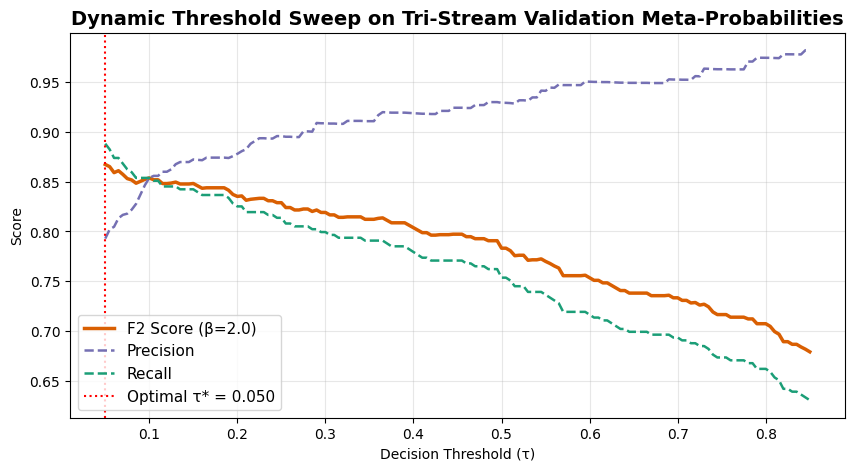

In [11]:
# ── 11. DYNAMIC F2 THRESHOLD OPTIMIZATION ───────────────────────────────────
thresholds = np.linspace(0.05, 0.85, 161)
f2_scores, precisions, recalls = [], [], []

best_tau, best_val_f2 = 0.5, 0.0

for tau in thresholds:
    preds = (P_ensemble_val >= tau).astype(int)
    f2 = fbeta_score(y.iloc[idx_val], preds, beta=2.0)
    p  = precision_score(y.iloc[idx_val], preds, zero_division=0)
    r  = recall_score(y.iloc[idx_val], preds, zero_division=0)
    
    f2_scores.append(f2)
    precisions.append(p)
    recalls.append(r)
    
    if f2 > best_val_f2:
        best_val_f2 = f2
        best_tau    = tau

print(f"""
============================================================
🎯 OPTIMAL DECISION THRESHOLD (τ*) FOUND
============================================================
Optimal Threshold (τ*)   : {best_tau:.3f}
Peak Validation F2 Score : {best_val_f2:.4f}
============================================================
""")

# Plot Threshold Optimization Curves
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f2_scores, label='F2 Score (β=2.0)', color='#D95F02', linewidth=2.5)
plt.plot(thresholds, precisions, label='Precision', color='#7570B3', linestyle='--', linewidth=1.8)
plt.plot(thresholds, recalls, label='Recall', color='#1B9E77', linestyle='--', linewidth=1.8)
plt.axvline(x=best_tau, color='red', linestyle=':', label=f'Optimal τ* = {best_tau:.3f}')
plt.title("Dynamic Threshold Sweep on Tri-Stream Validation Meta-Probabilities", fontsize=14, weight='bold')
plt.xlabel("Decision Threshold (τ)")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize=11)
plt.show()

# 12. 🏆 FINAL EVALUATION ON UNSEEN TEST SET & 4-PANEL DIAGNOSTICS


🚀 FINAL PIPELINE (v9 Tri-Stream) TEST SET METRICS
Final Test F2 Score       : 0.8842  (Target: > 0.8500)
Final Test Accuracy       : 0.9984  (99.84%)
Final Test Precision      : 0.8082
Final Test Recall         : 0.9054
Final Test ROC-AUC        : 0.9994


Detailed Classification Report on Unseen Test Set:
              precision    recall  f1-score   support

           0     0.9995    0.9989    0.9992     66764
           1     0.8082    0.9054    0.8541       349

    accuracy                         0.9984     67113
   macro avg     0.9038    0.9522    0.9266     67113
weighted avg     0.9985    0.9984    0.9984     67113



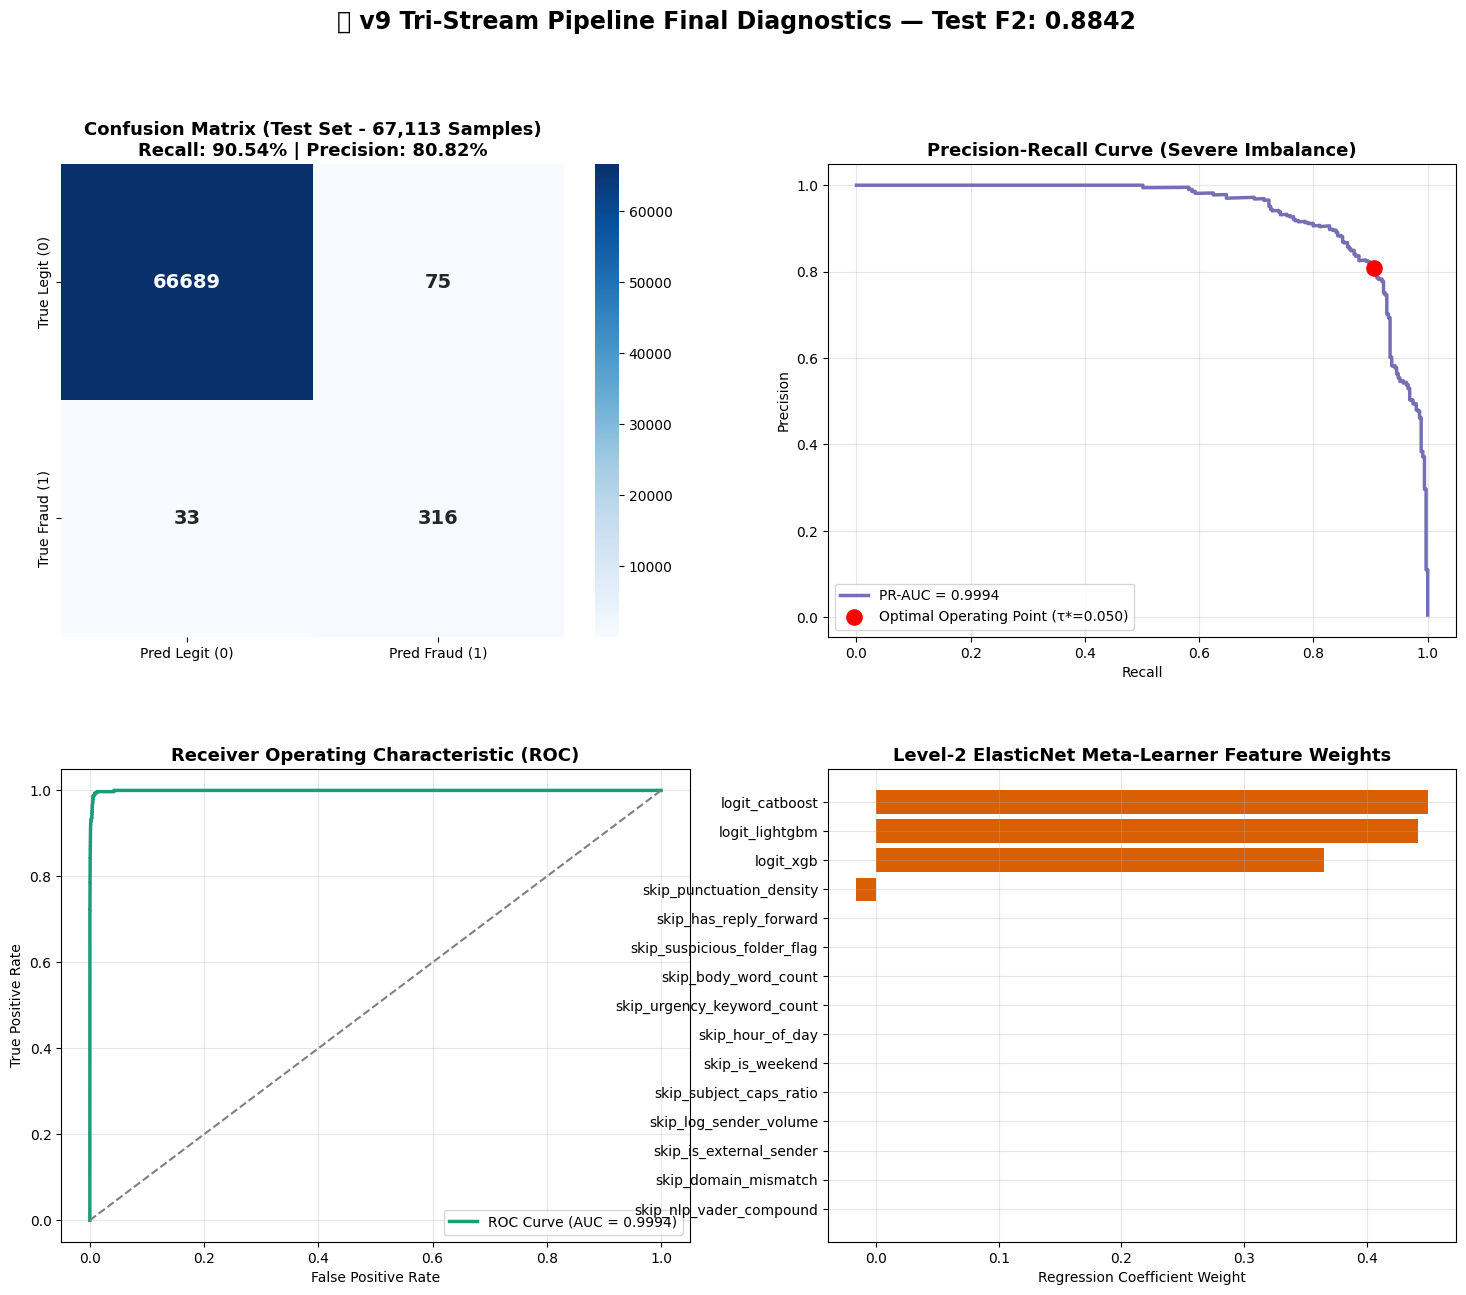

In [12]:
# ── 12. FINAL UNSEEN TEST EVALUATION & 4-PANEL DIAGNOSTICS ──────────────────
y_test_true = y.iloc[idx_test].values
y_test_pred = (P_ensemble_ts >= best_tau).astype(int)

final_f2   = fbeta_score(y_test_true, y_test_pred, beta=2.0)
final_acc  = accuracy_score(y_test_true, y_test_pred)
final_prec = precision_score(y_test_true, y_test_pred)
final_rec  = recall_score(y_test_true, y_test_pred)
final_auc  = roc_auc_score(y_test_true, P_ensemble_ts)

print(f"""
============================================================
🚀 FINAL PIPELINE (v9 Tri-Stream) TEST SET METRICS
============================================================
Final Test F2 Score       : {final_f2:.4f}  (Target: > 0.8500)
Final Test Accuracy       : {final_acc:.4f}  ({final_acc*100:.2f}%)
Final Test Precision      : {final_prec:.4f}
Final Test Recall         : {final_rec:.4f}
Final Test ROC-AUC        : {final_auc:.4f}
============================================================
""")

print("\nDetailed Classification Report on Unseen Test Set:")
print(classification_report(y_test_true, y_test_pred, digits=4))

# ── 4-Panel Diagnostic Figure ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.28, wspace=0.22)

# 1. Confusion Matrix
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Pred Legit (0)', 'Pred Fraud (1)'],
            yticklabels=['True Legit (0)', 'True Fraud (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0, 0].set_title(f"Confusion Matrix (Test Set - {len(y_test_true):,} Samples)\nRecall: {final_rec*100:.2f}% | Precision: {final_prec*100:.2f}%", fontsize=13, weight='bold')

# 2. Precision-Recall Curve with Optimal Operating Point
prec_curve, rec_curve, _ = precision_recall_curve(y_test_true, P_ensemble_ts)
axes[0, 1].plot(rec_curve, prec_curve, color='#7570B3', linewidth=2.5, label=f'PR-AUC = {final_auc:.4f}')
axes[0, 1].scatter([final_rec], [final_prec], color='red', s=120, zorder=5, label=f'Optimal Operating Point (τ*={best_tau:.3f})')
axes[0, 1].set_title("Precision-Recall Curve (Severe Imbalance)", fontsize=13, weight='bold')
axes[0, 1].set_xlabel("Recall")
axes[0, 1].set_ylabel("Precision")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='lower left')

# 3. ROC-AUC Curve
fpr, tpr, _ = roc_curve(y_test_true, P_ensemble_ts)
axes[1, 0].plot(fpr, tpr, color='#1B9E77', linewidth=2.5, label=f'ROC Curve (AUC = {final_auc:.4f})')
axes[1, 0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[1, 0].set_title("Receiver Operating Characteristic (ROC)", fontsize=13, weight='bold')
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend(loc='lower right')

# 4. Meta-Learner Feature Importance Weights
coefs = final_meta_learner.coef_[0]
sorted_idx = np.argsort(np.abs(coefs))
axes[1, 1].barh(np.array(meta_feature_names)[sorted_idx], coefs[sorted_idx], color='#D95F02')
axes[1, 1].set_title("Level-2 ElasticNet Meta-Learner Feature Weights", fontsize=13, weight='bold')
axes[1, 1].set_xlabel("Regression Coefficient Weight")
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"🏆 v9 Tri-Stream Pipeline Final Diagnostics — Test F2: {final_f2:.4f}", fontsize=17, weight='bold', y=0.99)
plt.show()